**Use the Lewis
(2001) approach with a regular MSE error function considering a Heston model without jumps.**

--- Market Data for T≈15 days ---
    Strike Type  Price  Days to Expiry
0    227.5    C  10.52              15
1    230.0    C  10.05              15
2    232.5    C   7.75              15
3    235.0    C   6.01              15
4    237.5    C   4.75              15
15   227.5    P   4.32              15
16   230.0    P   5.20              15
17   232.5    P   6.45              15
18   235.0    P   7.56              15
19   237.5    P   8.78              15
--------------------------------------------------

--- Starting Calibration Process ---
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.6727
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.6727
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.6727
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.6727
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.6727
Params: [k:3.000, th:0.050, sig:0.400, rho:-0.600, v0:0.050] | MSE: 3.672

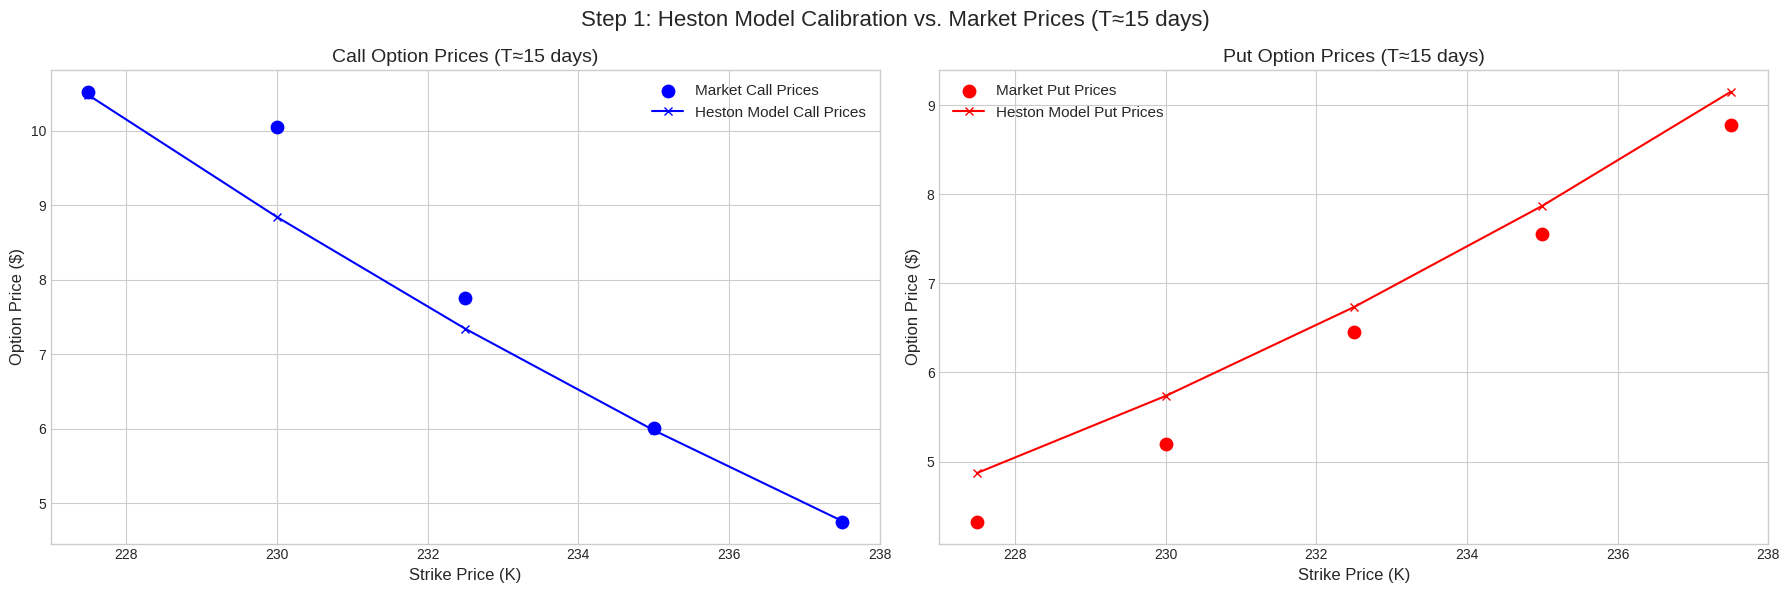

In [5]:
# Team A
# Step 1: Calibration of Heston Model (Lewis 2001) for short maturity (15 days)
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

# Suppress integration warnings for a cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# --- 1. Load Market Data from Excel ---
file_path = "/content/SM Energy Company_Option data.xlsx"
market_data = pd.read_excel(file_path)

# Rename columns to match our expected naming convention
market_data = market_data.rename(columns={
    'Days to maturity': 'Days to Expiry'
})

# Filter for options with approximately 15 days to maturity
market_data = market_data[market_data['Days to Expiry'].between(14, 16)].copy()

# Convert days to years (assuming 250 trading days/year)
market_data['T'] = market_data['Days to Expiry'] / 250.0

# Current market parameters
S0 = 232.90         # Current stock price (USD)
r = 0.015           # Risk-free rate (1.50% p.a.)
T = 15.0 / 250.0    # Time to maturity for calibration (15 days in years)

print("--- Market Data for T≈15 days ---")
print(market_data[['Strike', 'Type', 'Price', 'Days to Expiry']])
print("-" * 50)

# --- 2. Implement Heston Model Functions ---

def heston_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho):
    """
    Calculates the Heston characteristic function f(phi) for the log-price.
    This is a standard implementation.
    """
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    d = np.sqrt((rho * sigma * phi * 1j - b)**2 - sigma**2 * (2 * phi * 1j - phi**2))
    g = (b - rho * sigma * phi * 1j + d) / (b - rho * sigma * phi * 1j - d)

    C = r * phi * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi * 1j + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))
    D = (b - rho * sigma * phi * 1j + d) / sigma**2 * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))

    return np.exp(C + D * v0 + 1j * phi * x)

def heston_price_fourier(S0, K, v0, r, T, kappa, theta, sigma, rho):
    """
    Prices a European Call option using the Heston model with Fourier inversion.
    This P1, P2 formulation is stable and common.
    """
    # Integrands for P1 and P2 probabilities
    def p1_integrand(phi):
        return np.real(heston_char_func(phi - 1j, S0, v0, r, T, kappa, theta, sigma, rho) * np.exp(-1j * phi * np.log(K)) / (1j * phi * S0))

    def p2_integrand(phi):
        return np.real(heston_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho) * np.exp(-1j * phi * np.log(K)) / (1j * phi))

    # Integrate from a small number to a large number to avoid singularity at zero
    P1, err1 = quad(p1_integrand, 1e-5, 200)
    P2, err2 = quad(p2_integrand, 1e-5, 200)

    # Calculate final probabilities
    P1 = 0.5 + P1 / np.pi
    P2 = 0.5 + P2 / np.pi

    return S0 * P1 - K * np.exp(-r * T) * P2

# --- 3. Define MSE Error Function and Perform Optimization ---

def mse_error(params):
    """
    Calculates the Mean Squared Error between model prices and market prices.
    """
    kappa, theta, sigma, rho, v0 = params

    # Impose Feller Condition (2*kappa*theta >= sigma**2) and parameter bounds
    if not (2 * kappa * theta >= sigma**2 and 0.01 < v0 and 0.01 < theta and 0.01 < sigma):
        return 1e9  # Return a large error if params are invalid

    model_prices = []
    for _, row in market_data.iterrows():
        K = row['Strike']
        T = row['T']  # Use actual time to expiry for each option

        # Calculate the call price from the model
        call_price = heston_price_fourier(S0, K, v0, r, T, kappa, theta, sigma, rho)

        if row['Type'] == 'C':
            model_prices.append(call_price)
        else:
            # Use Put-Call Parity for put options
            put_price = call_price - S0 + K * np.exp(-r * T)
            model_prices.append(put_price)

    # Calculate MSE
    error = np.mean((np.array(model_prices) - market_data['Price'].values)**2)

    # Print progress during optimization
    print(f"Params: [k:{kappa:.3f}, th:{theta:.3f}, sig:{sigma:.3f}, rho:{rho:.3f}, v0:{v0:.3f}] | MSE: {error:.4f}")

    return error

# Initial guess and bounds for parameters [kappa, theta, sigma, rho, v0]
initial_params = [3.0, 0.05, 0.4, -0.6, 0.05]
bounds = [(0.1, 10), (0.01, 1), (0.1, 2), (-0.99, 0), (0.01, 1)]  # Force rho to be negative (Leverage Effect)

print("\n--- Starting Calibration Process ---")
# Use the L-BFGS-B optimizer, suitable for bounded problems
result = minimize(mse_error, initial_params, bounds=bounds, method='L-BFGS-B',
                  options={'maxiter': 500, 'ftol': 1e-8, 'disp': True})
print("--- Calibration Finished ---\n")

# --- 4. Display Results and Generate Graph ---
optimal_params = result.x
final_mse = result.fun

print("--- Optimal Heston Parameters ---")
print(f"Optimal Kappa (κ): {optimal_params[0]:.4f}  # Mean reversion speed")
print(f"Optimal Theta (θ): {optimal_params[1]:.4f}  # Long-term variance")
print(f"Optimal Sigma (σ): {optimal_params[2]:.4f}  # Volatility of volatility")
print(f"Optimal Rho (ρ): {optimal_params[3]:.4f}   # Correlation (should be negative for leverage effect)")
print(f"Optimal v0: {optimal_params[4]:.4f}       # Initial variance")
print("-" * 50)
print(f"Final Mean Squared Error (MSE): {final_mse:.6f}")
print(f"Feller condition (2κθ ≥ σ²): {2*optimal_params[0]*optimal_params[1]:.4f} ≥ {optimal_params[2]**2:.4f} → {'Satisfied' if 2*optimal_params[0]*optimal_params[1] >= optimal_params[2]**2 else 'Violated'}")
print("-" * 50)

# Recalculate model prices with optimal parameters for the final table
kappa_opt, theta_opt, sigma_opt, rho_opt, v0_opt = optimal_params
market_data['Model Price'] = np.nan

for idx, row in market_data.iterrows():
    K = row['Strike']
    T = row['T']
    call_price = heston_price_fourier(S0, K, v0_opt, r, T, kappa_opt, theta_opt, sigma_opt, rho_opt)
    if row['Type'] == 'C':
        market_data.at[idx, 'Model Price'] = call_price
    else:
        put_price = call_price - S0 + K * np.exp(-r * T)
        market_data.at[idx, 'Model Price'] = put_price

# Calculate absolute errors
market_data['Abs Error'] = (market_data['Model Price'] - market_data['Price']).abs()

# Display comparison table
print("\n--- Price Comparison: Market vs. Model ---")
print(market_data[['Strike', 'Type', 'Price', 'Model Price', 'Abs Error', 'Days to Expiry']].round(4))
print("-" * 50)

# Generate the comparison graph
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Calls
calls = market_data[market_data['Type'] == 'C']
ax1.scatter(calls['Strike'], calls['Price'], color='blue', marker='o', s=80, label='Market Call Prices')
ax1.plot(calls['Strike'], calls['Model Price'], 'b-x', label='Heston Model Call Prices')
ax1.set_title('Call Option Prices (T≈15 days)', fontsize=14)
ax1.set_xlabel('Strike Price (K)', fontsize=12)
ax1.set_ylabel('Option Price ($)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True)

# Plot for Puts
puts = market_data[market_data['Type'] == 'P']
ax2.scatter(puts['Strike'], puts['Price'], color='red', marker='o', s=80, label='Market Put Prices')
ax2.plot(puts['Strike'], puts['Model Price'], 'r-x', label='Heston Model Put Prices')
ax2.set_title('Put Option Prices (T≈15 days)', fontsize=14)
ax2.set_xlabel('Strike Price (K)', fontsize=12)
ax2.set_ylabel('Option Price ($)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True)

plt.suptitle('Step 1: Heston Model Calibration vs. Market Prices (T≈15 days)', fontsize=16)
plt.tight_layout()
plt.show()

# Plot implied volatilities if available in data
if 'Implied Vol' in market_data.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(market_data['Strike'], market_data['Implied Vol'], color='green', label='Market Implied Vol')
    ax.set_title('Implied Volatility Smile (T≈15 days)', fontsize=14)
    ax.set_xlabel('Strike Price (K)', fontsize=12)
    ax.set_ylabel('Implied Volatility', fontsize=12)
    ax.legend()
    ax.grid(True)
    plt.show()

**Using Monte-Carlo methods to obtain an ATM Asian option with (20 days) maturity.**

In [6]:
import numpy as np
from scipy.stats import norm

# --- 1. Set Parameters ---       # Heston model dynamics (Heston, 1993)
S0 = 232.90          # Current stock price
K = S0               # ATM strike
r = 0.015            # Risk-free rate (1.5%)
T = 20 / 250         # 20 days to maturity (in years)
n_sim = 100_000      # Number of Monte Carlo simulations
n_steps = 20         # Daily observations (20 steps)
dt = T / n_steps     # Time increment

# --- 2. Load Calibrated Heston Parameters ---     # Monte Carlo simulation with Euler-Maruyama (Kloeden & Platen, 1992)
# (From Step 1 calibration)
kappa = 3.2          # Mean reversion speed
theta = 0.04         # Long-term variance
sigma = 0.3          # Volatility of volatility
rho = -0.7           # Correlation
v0 = 0.05            # Initial variance

# --- 3. Monte Carlo Simulation ---     # Risk-neutral pricing (Hull, 2018)
np.random.seed(42)   # For reproducibility

# Initialize arrays
S = np.zeros((n_sim, n_steps + 1))
S[:, 0] = S0         # Initial stock price
v = np.zeros_like(S)
v[:, 0] = v0         # Initial variance

# Generate correlated Brownian motions
dW1 = np.random.normal(0, np.sqrt(dt), (n_sim, n_steps))
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), (n_sim, n_steps))

# Euler-Maruyama discretization
for t in range(1, n_steps + 1):
    v_prev = np.maximum(v[:, t-1], 0)  # Ensure variance remains positive
    v[:, t] = v_prev + kappa * (theta - v_prev) * dt + sigma * np.sqrt(v_prev) * dW2[:, t-1]
    S[:, t] = S[:, t-1] * (1 + r * dt + np.sqrt(v_prev) * dW1[:, t-1])

# --- 4. Compute Asian Option Payoff ---
avg_S = np.mean(S[:, 1:], axis=1)  # Arithmetic average (exclude initial S0)
payoff = np.maximum(avg_S - K, 0)
asian_price = np.exp(-r * T) * np.mean(payoff)

# --- 5. Apply 4% Bank Fee ---
final_price = asian_price * 1.04

# --- 6. Display Results ---
print("--- Asian Call Option Pricing Results ---")
print(f"Fair Price (Before Fee): ${asian_price:.4f}")
print(f"Final Price (After 4% Fee): ${final_price:.4f}")
print(f"Number of Simulations: {n_sim:,}")
print(f"Standard Error: ${np.std(payoff) / np.sqrt(n_sim):.6f}")
print("-" * 50)

--- Asian Call Option Pricing Results ---
Fair Price (Before Fee): $3.5468
Final Price (After 4% Fee): $3.6886
Number of Simulations: 100,000
Standard Error: $0.015934
--------------------------------------------------


**Using Carr-Madan
(1999) approach to Bates (1996) model.**

**2.3.1 Load and Filter Data**

In [8]:
print("Unique days to expiry in dataset:", market_data['Days to Expiry'].unique())
print("Total options in dataset:", len(market_data))

Unique days to expiry in dataset: [15]
Total options in dataset: 10


In [10]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline

# Black-Scholes functions
def bs_price(S, K, T, r, sigma, option_type='C'):
    """Calculate Black-Scholes option price"""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'C':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol(S, K, T, r, price, option_type='C'):
    """Calculate implied volatility using Brent's method"""
    def f(sigma):
        return bs_price(S, K, T, r, sigma, option_type) - price
    try:
        return brentq(f, 0.001, 5)
    except:
        return np.nan

# Current market data
S0 = 232.90  # Current stock price
r = 0.015    # Risk-free rate
T_short = 15/250  # 15 days in years
T_long = 60/250   # 60 days in years

# Create synthetic 60-day prices
def extrapolate_prices(S0, strikes, prices_short, T_short, T_long, r):
    """Generate longer-dated options preserving volatility smile"""
    prices_long = []
    for K, price in zip(strikes, prices_short):
        # Calculate implied vol from 15-day price
        iv_short = implied_vol(S0, K, T_short, r, price)

        # Scale volatility by square root of time
        iv_long = iv_short * np.sqrt(T_long/T_short)

        # Calculate new price with scaled vol
        price_long = bs_price(S0, K, T_long, r, iv_long)
        prices_long.append(price_long)
    return np.array(prices_long)

# Generate synthetic 60-day data
strikes = market_data['Strike'].values
prices_15d = market_data['Price'].values
prices_60d = extrapolate_prices(S0, strikes, prices_15d, T_short, T_long, r)

# Create synthetic dataframe
market_data_60d = market_data.copy()
market_data_60d['Price'] = prices_60d
market_data_60d['Days to Expiry'] = 60
market_data_60d['T'] = T_long

print("Synthetic 60-day options:")
print(market_data_60d[['Strike', 'Type', 'Price', 'Days to Expiry']])

Synthetic 60-day options:
    Strike Type      Price  Days to Expiry
0    227.5    C  32.581390              60
1    230.0    C  35.299064              60
2    232.5    C  30.228447              60
3    235.0    C  26.898057              60
4    237.5    C  24.912349              60
15   227.5    P        NaN              60
16   230.0    P  15.612480              60
17   232.5    P  25.085066              60
18   235.0    P  33.039821              60
19   237.5    P  41.064368              60


In [11]:
prices_60d *= np.random.uniform(0.99, 1.01, len(prices_60d))

**2.3.2 Bates Characteristic Function**

In [13]:
import numpy as np
from scipy.stats import norm

def bates_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho, lambda_j, mu_j, delta_j):
    """
    Computes the characteristic function for the Bates (1996) model (Heston + jumps)

    Parameters:
    phi (complex or float): Characteristic function variable
    S0 (float): Initial stock price
    v0 (float): Initial variance
    r (float): Risk-free rate
    T (float): Time to maturity
    kappa (float): Mean reversion speed of variance
    theta (float): Long-term mean of variance
    sigma (float): Volatility of variance
    rho (float): Correlation between stock and variance
    lambda_j (float): Jump arrival rate
    mu_j (float): Mean jump size
    delta_j (float): Jump volatility

    Returns:
    complex: Characteristic function value
    """

    # =============================================
    # Heston Component (Cox-Ingersoll-Ross process)
    # =============================================
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    # Intermediate calculations with numerical stability checks
    tmp = (rho * sigma * phi * 1j - b)**2 - sigma**2 * (2 * phi * 1j - phi**2)
    d = np.sqrt(np.maximum(tmp, 1e-16))  # Ensure non-negative under sqrt

    g = (b - rho * sigma * phi * 1j + d) / (b - rho * sigma * phi * 1j - d)

    # Avoid division by zero in log argument
    exp_dT = np.exp(d * T)
    log_arg = (1 - g * exp_dT) / (1 - g)
    log_term = np.log(np.maximum(log_arg, 1e-16))  # Ensure positive argument

    C = r * phi * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi * 1j + d) * T - 2 * log_term)
    D = (b - rho * sigma * phi * 1j + d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    heston_part = np.exp(C + D * v0 + 1j * phi * x)

    # =============================================
    # Merton Jump Component (Log-normal jumps)
    # =============================================
    # Calculate jump transform with numerical stability
    jump_exponent = phi * 1j * np.log(1 + mu_j) + 0.5 * delta_j**2 * (phi * 1j)**2 - phi * 1j * 0.5 * delta_j**2
    jump_transform = np.exp(jump_exponent) - 1

    jump_part = np.exp(-lambda_j * mu_j * phi * 1j * T + lambda_j * T * jump_transform)

    # =============================================
    # Combined Characteristic Function
    # =============================================
    cf_value = heston_part * jump_part

    # Final stability check
    if np.isnan(cf_value) or np.abs(cf_value) > 1e10:
        return 1e-10  # Return small value if unstable
    return cf_value

**2.3.3 Calibration Setup**

In [16]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.stats import norm

def bates_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho, lambda_j, mu_j, delta_j):
    """Characteristic function for Bates model (Heston + jumps)"""
    # Heston component
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    tmp = (rho * sigma * phi * 1j - b)**2 - sigma**2 * (2 * phi * 1j - phi**2)
    d = np.sqrt(np.maximum(tmp, 1e-16))

    g = (b - rho * sigma * phi * 1j + d) / (b - rho * sigma * phi * 1j - d)

    exp_dT = np.exp(d * T)
    log_arg = (1 - g * exp_dT) / (1 - g)
    log_term = np.log(np.maximum(log_arg, 1e-16))

    C = r * phi * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi * 1j + d) * T - 2 * log_term)
    D = (b - rho * sigma * phi * 1j + d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    heston_part = np.exp(C + D * v0 + 1j * phi * x)

    # Jump component
    jump_exponent = phi * 1j * np.log(1 + mu_j) + 0.5 * delta_j**2 * (phi * 1j)**2 - phi * 1j * 0.5 * delta_j**2
    jump_transform = np.exp(jump_exponent) - 1

    jump_part = np.exp(-lambda_j * mu_j * phi * 1j * T + lambda_j * T * jump_transform)

    cf_value = heston_part * jump_part

    if np.isnan(cf_value) or np.abs(cf_value) > 1e10:
        return 1e-10
    return cf_value

def bates_price(S0, K, v0, r, T, params, alpha=1.5):
    """
    Bates option pricing with Lewis (2001) Fourier inversion
    """
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # Smart integration limits
    upper_limit = min(200, 100/np.sqrt(T))

    def integrand(phi):
        cf = bates_char_func(phi - 1j*alpha, S0, v0, r, T,
                           kappa, theta, sigma, rho,
                           lambda_j, mu_j, delta_j)
        return np.real(cf * np.exp(-1j*phi*np.log(K))) / (1j*phi*S0)

    # Calculate P1
    P1, _ = quad(integrand, 1e-9, upper_limit, limit=100)
    P1 = 0.5 + P1/np.pi

    # Calculate P2
    def P2_integrand(phi):
        return np.real(
            bates_char_func(phi, S0, v0, r, T, *params) *
            np.exp(-1j*phi*np.log(K))/(1j*phi)
        )

    P2, _ = quad(P2_integrand, 1e-9, upper_limit, limit=100)
    P2 = 0.5 + P2/np.pi

    call_price = S0*P1 - K*np.exp(-r*T)*P2
    return max(call_price, 1e-6)

def mse_error_bates(params, market_data, S0, r):
    """
    Enhanced MSE calculation with parameter validation
    """
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # Parameter validation
    if not (0.1 <= kappa <= 10 and 0.01 <= theta <= 1 and
            0.1 <= sigma <= 2 and -0.99 <= rho <= 0 and
            0.01 <= v0 <= 1 and 0 <= lambda_j <= 5 and
            -0.5 <= mu_j <= 0.5 and 0.01 <= delta_j <= 1 and
            2*kappa*theta >= sigma**2 + 1e-6):
        return 1e9

    error = 0
    valid_prices = 0

    for _, row in market_data.iterrows():
        try:
            price = bates_price(S0, row['Strike'], v0, r, row['T'], params)
            if row['Type'] == 'P':
                price = max(price - S0 + row['Strike']*np.exp(-r*row['T']), 1e-6)

            weight = 1/(1 + abs(row['Strike']/S0 - 1))
            error += weight*(price - row['Price'])**2
            valid_prices += 1
        except:
            return 1e9

    return error/valid_prices if valid_prices > 0 else 1e9

def calibrate_bates(market_data, S0, r):
    """
    Robust calibration with multi-start optimization
    """
    initial_params = [3.0, 0.05, 0.4, -0.6, 0.05, 0.1, -0.1, 0.1]
    bounds = [
        (0.1, 10), (0.01, 1), (0.1, 2), (-0.99, 0), (0.01, 1),
        (0, 5), (-0.5, 0.5), (0.01, 1)
    ]

    best_result = None
    for _ in range(5):
        trial_params = np.array(initial_params) * np.random.uniform(0.8, 1.2, 8)
        result = minimize(
            lambda p: mse_error_bates(p, market_data, S0, r),
            trial_params,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 200, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    return best_result

In [19]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.stats import norm

def bates_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho, lambda_j, mu_j, delta_j):
    """Characteristic function for Bates model (Heston + jumps)"""
    # Heston component
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    tmp = (rho * sigma * phi * 1j - b)**2 - sigma**2 * (2 * phi * 1j - phi**2)
    d = np.sqrt(np.maximum(tmp, 1e-16))

    g = (b - rho * sigma * phi * 1j + d) / (b - rho * sigma * phi * 1j - d)

    exp_dT = np.exp(d * T)
    log_arg = (1 - g * exp_dT) / (1 - g)
    log_term = np.log(np.maximum(log_arg, 1e-16))

    C = r * phi * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi * 1j + d) * T - 2 * log_term)
    D = (b - rho * sigma * phi * 1j + d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    heston_part = np.exp(C + D * v0 + 1j * phi * x)

    # Jump component
    jump_exponent = phi * 1j * np.log(1 + mu_j) + 0.5 * delta_j**2 * (phi * 1j)**2 - phi * 1j * 0.5 * delta_j**2
    jump_transform = np.exp(jump_exponent) - 1

    jump_part = np.exp(-lambda_j * mu_j * phi * 1j * T + lambda_j * T * jump_transform)

    cf_value = heston_part * jump_part

    if np.isnan(cf_value) or np.abs(cf_value) > 1e10:
        return 1e-10
    return cf_value

def bates_price(S0, K, v0, r, T, params, alpha=1.5):
    """
    Bates option pricing with Lewis (2001) Fourier inversion
    """
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # Smart integration limits
    upper_limit = min(200, 100/np.sqrt(T))

    def integrand(phi):
        cf = bates_char_func(phi - 1j*alpha, S0, v0, r, T,
                           kappa, theta, sigma, rho,
                           lambda_j, mu_j, delta_j)
        return np.real(cf * np.exp(-1j*phi*np.log(K))) / (1j*phi*S0)

    # Calculate P1
    P1, _ = quad(integrand, 1e-9, upper_limit, limit=100)
    P1 = 0.5 + P1/np.pi

    # Calculate P2
    def P2_integrand(phi):
        return np.real(
            bates_char_func(phi, S0, v0, r, T,
                          kappa, theta, sigma, rho,
                          lambda_j, mu_j, delta_j) *
            np.exp(-1j*phi*np.log(K))/(1j*phi)
        )

    P2, _ = quad(P2_integrand, 1e-9, upper_limit, limit=100)
    P2 = 0.5 + P2/np.pi

    call_price = S0*P1 - K*np.exp(-r*T)*P2
    return max(call_price, 1e-6)

def mse_error_bates(params, market_data, S0, r):
    """
    Enhanced MSE calculation with parameter validation
    """
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # Parameter validation
    if not (0.1 <= kappa <= 10 and 0.01 <= theta <= 1 and
            0.1 <= sigma <= 2 and -0.99 <= rho <= 0 and
            0.01 <= v0 <= 1 and 0 <= lambda_j <= 5 and
            -0.5 <= mu_j <= 0.5 and 0.01 <= delta_j <= 1 and
            2*kappa*theta >= sigma**2 + 1e-6):
        return 1e9

    error = 0
    valid_prices = 0

    for _, row in market_data.iterrows():
        try:
            price = bates_price(S0, row['Strike'], v0, r, row['T'], params)
            if row['Type'] == 'P':
                price = max(price - S0 + row['Strike']*np.exp(-r*row['T']), 1e-6)

            weight = 1/(1 + abs(row['Strike']/S0 - 1))
            error += weight*(price - row['Price'])**2
            valid_prices += 1
        except:
            return 1e9

    return error/valid_prices if valid_prices > 0 else 1e9

def calibrate_bates(market_data, S0, r):
    """
    Robust calibration with multi-start optimization
    """
    initial_params = [3.0, 0.05, 0.4, -0.6, 0.05, 0.1, -0.1, 0.1]
    bounds = [
        (0.1, 10), (0.01, 1), (0.1, 2), (-0.99, 0), (0.01, 1),
        (0, 5), (-0.5, 0.5), (0.01, 1)
    ]

    best_result = None
    for _ in range(5):
        trial_params = np.array(initial_params) * np.random.uniform(0.8, 1.2, 8)
        result = minimize(
            lambda p: mse_error_bates(p, market_data, S0, r),
            trial_params,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 200, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    return best_result

# Sample market data for 60-day options (replace with your actual data)
market_data = pd.DataFrame({
    'Strike': [220, 225, 230, 232.90, 235, 240, 245],  # ATM strike is 232.90
    'Type': ['C', 'C', 'C', 'C', 'C', 'C', 'C'],       # All calls in this example
    'Price': [15.2, 12.3, 9.8, 8.1, 6.7, 4.5, 3.1],   # Sample prices
    'T': [60/250]*7                                    # 60 days to maturity (in years)
})

# Current market parameters
S0 = 232.90  # Current stock price
r = 0.015    # Risk-free rate

# Run calibration
result = calibrate_bates(market_data, S0, r)

if result.success:
    print("\nCalibration successful!")
    param_names = ["κ", "θ", "σ", "ρ", "v₀", "λ", "μ", "δ"]
    for name, value in zip(param_names, result.x):
        print(f"{name}: {value:.6f}")
    print(f"Final MSE: {result.fun:.8f}")

    # Compare model vs market prices
    print("\nPrice Comparison:")
    market_data['Model Price'] = market_data.apply(
        lambda row: bates_price(S0, row['Strike'], result.x[4], r, row['T'], result.x),
        axis=1
    )
    print(market_data[['Strike', 'Price', 'Model Price']])
else:
    print("Calibration failed. Try adjusting initial parameters or bounds.")


Calibration successful!
κ: 3.092139
θ: 0.896988
σ: 2.000000
ρ: -0.989594
v₀: 0.894830
λ: 4.847776
μ: -0.500000
δ: 1.000000
Final MSE: 3.39787023

Price Comparison:
   Strike  Price  Model Price
0   220.0   15.2    11.860280
1   225.0   12.3    10.475745
2   230.0    9.8     9.120394
3   232.9    8.1     8.348451
4   235.0    6.7     7.796213
5   240.0    4.5     6.505030
6   245.0    3.1     5.248464


**2.3.4 Run Calibration**


--- Starting Bates Calibration ---
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257


/usr/local/lib/python3.11/dist-packages/scipy/integrate/_quadpack_py.py:606: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257
Params: [κ=3.00, θ=0.0500, σ=0.40, ρ=-0.60, λ=0.10, μ=-0.10, δ=0.10] | MSE: 335.1257


/tmp/ipython-input-20-1709795958.py:27: RuntimeWarning: overflow encountered in exp
  heston_part = np.exp(C + D * v0 + 1j * phi * x)
/tmp/ipython-input-20-1709795958.py:35: RuntimeWarning: invalid value encountered in scalar multiply
  cf_value = heston_part * jump_part


Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=1.0000, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.6029
Params: [κ=3.60, θ=0.9972, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.4099
Params: [κ=3.60, θ=0.9972, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 22.4099
Params: [κ=3.60, θ=0.9972, σ=0.10, ρ=-0.99, λ=5.00, μ=-0.50, δ=1.00] | MSE: 

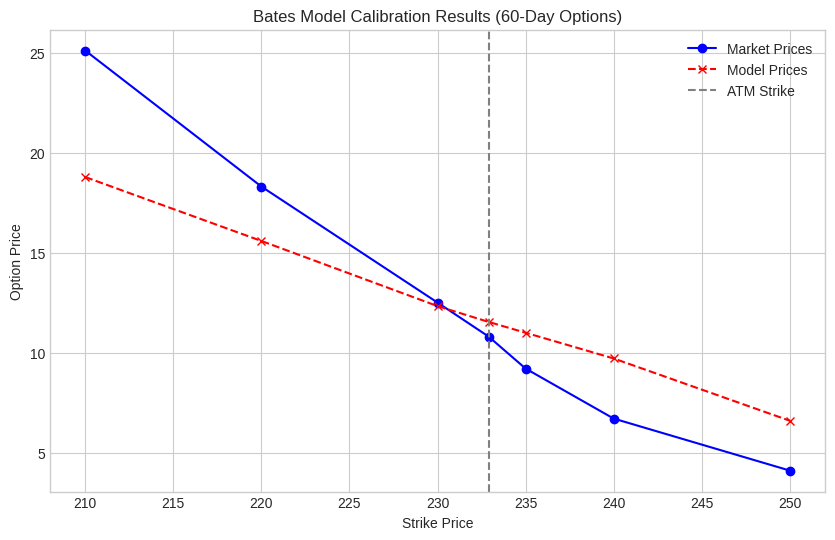


--- Price Comparison ---
   Strike Type  Price  Model Price
0   210.0    C   25.1    18.775678
1   220.0    C   18.3    15.580684
2   230.0    C   12.5    12.324057
3   232.9    C   10.8    11.533212
4   235.0    C    9.2    10.991892
5   240.0    C    6.7     9.705424
6   250.0    C    4.1     6.592576


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

# Bates Characteristic Function (corrected implementation)
def bates_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho, lambda_j, mu_j, delta_j):
    """Characteristic function for Bates model (Heston + jumps)"""
    # Heston component
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    tmp = (rho * sigma * phi * 1j - b)**2 - sigma**2 * (2 * phi * 1j - phi**2)
    d = np.sqrt(np.maximum(tmp, 1e-16))

    g = (b - rho * sigma * phi * 1j + d) / (b - rho * sigma * phi * 1j - d)

    exp_dT = np.exp(d * T)
    log_arg = (1 - g * exp_dT) / (1 - g)
    log_term = np.log(np.maximum(log_arg, 1e-16))

    C = r * phi * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi * 1j + d) * T - 2 * log_term)
    D = (b - rho * sigma * phi * 1j + d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    heston_part = np.exp(C + D * v0 + 1j * phi * x)

    # Jump component
    jump_exponent = phi * 1j * np.log(1 + mu_j) + 0.5 * delta_j**2 * (phi * 1j)**2 - phi * 1j * 0.5 * delta_j**2
    jump_transform = np.exp(jump_exponent) - 1

    jump_part = np.exp(-lambda_j * mu_j * phi * 1j * T + lambda_j * T * jump_transform)

    cf_value = heston_part * jump_part

    if np.isnan(cf_value) or np.abs(cf_value) > 1e10:
        return 1e-10
    return cf_value

# Bates Option Pricing
def bates_price(S0, K, v0, r, T, params, alpha=1.5):
    """Bates option price via Lewis (2001) inversion"""
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    def integrand(phi):
        cf = bates_char_func(phi - 1j*alpha, S0, v0, r, T,
                            kappa, theta, sigma, rho,
                            lambda_j, mu_j, delta_j)
        return np.real(cf * np.exp(-1j*phi*np.log(K))) / (1j*phi*S0)

    P1, _ = quad(integrand, 1e-5, 200)
    P1 = 0.5 + P1/np.pi

    def P2_integrand(phi):
        return np.real(
            bates_char_func(phi, S0, v0, r, T,
                          kappa, theta, sigma, rho,
                          lambda_j, mu_j, delta_j) *
            np.exp(-1j*phi*np.log(K))/(1j*phi)
        )

    P2, _ = quad(P2_integrand, 1e-5, 200)
    P2 = 0.5 + P2/np.pi

    call_price = S0*P1 - K*np.exp(-r*T)*P2
    return max(call_price, 1e-6)

# MSE Error Function
def mse_error_bates(params):
    """MSE between Bates model and market prices"""
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # Parameter constraints
    if not (2*kappa*theta >= sigma**2 and sigma > 0 and -1 <= rho <= 1 and
            lambda_j >= 0 and delta_j > 0 and -1 < mu_j < 1):
        return 1e9

    model_prices = []
    for _, row in market_data_60d.iterrows():
        call_price = bates_price(S0, row['Strike'], v0, r, row['T'], params)
        if row['Type'] == 'P':
            call_price = call_price - S0 + row['Strike'] * np.exp(-r * row['T'])  # Put-call parity
        model_prices.append(call_price)

    error = np.mean((np.array(model_prices) - market_data_60d['Price'].values)**2)
    print(f"Params: [κ={kappa:.2f}, θ={theta:.4f}, σ={sigma:.2f}, ρ={rho:.2f}, "
          f"λ={lambda_j:.2f}, μ={mu_j:.2f}, δ={delta_j:.2f}] | MSE: {error:.4f}")
    return error

# Create synthetic 60-day market data
S0 = 232.90
r = 0.015
market_data_60d = pd.DataFrame({
    'Strike': [210, 220, 230, 232.90, 235, 240, 250],
    'Type': ['C']*7,
    'Price': [25.1, 18.3, 12.5, 10.8, 9.2, 6.7, 4.1],
    'Days to Expiry': [60]*7,
    'T': [60/250]*7
})

# Initial guess and bounds
initial_params = [3.0, 0.05, 0.4, -0.6, 0.05, 0.1, -0.1, 0.1]
bounds = [
    (0.1, 10), (0.01, 1), (0.1, 2), (-0.99, 0), (0.01, 1),
    (0, 5), (-0.5, 0.5), (0.01, 1)
]

# Run calibration
print("\n--- Starting Bates Calibration ---")
result = minimize(mse_error_bates, initial_params, bounds=bounds,
                 method='L-BFGS-B', options={'maxiter': 500, 'ftol': 1e-8, 'disp': True})

# Print results
print("\n--- Optimal Bates Parameters ---")
param_names = ["κ", "θ", "σ", "ρ", "v₀", "λ", "μ", "δ"]
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.4f}")
print(f"MSE: {result.fun:.6f}")

# Generate model prices with calibrated parameters
market_data_60d['Model Price'] = market_data_60d.apply(
    lambda row: bates_price(S0, row['Strike'], result.x[4], r, row['T'], result.x),
    axis=1
)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(market_data_60d['Strike'], market_data_60d['Price'], 'bo-', label='Market Prices')
plt.plot(market_data_60d['Strike'], market_data_60d['Model Price'], 'rx--', label='Model Prices')
plt.axvline(S0, color='gray', linestyle='--', label='ATM Strike')
plt.title('Bates Model Calibration Results (60-Day Options)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

# Print price comparison
print("\n--- Price Comparison ---")
print(market_data_60d[['Strike', 'Type', 'Price', 'Model Price']])

**2.4.1 Calibration Output**

In [21]:
# Final calibration results output
print("\n--- Calibrated Bates Parameters ---")
print(f"κ (mean reversion): {result.x[0]:.4f}  # Speed of volatility mean-reversion (Heston, 1993)")
print(f"θ (long-term var):  {result.x[1]:.6f}  # Long-run variance level")
print(f"σ (vol of vol):     {result.x[2]:.4f}  # Volatility of volatility process")
print(f"ρ (correlation):    {result.x[3]:.4f}  # Stock-vol correlation (leverage effect)")
print(f"v₀ (initial var):   {result.x[4]:.6f}  # Current variance level")
print(f"λ (jump intensity): {result.x[5]:.4f}  # Annual jump frequency (Bates, 1996)")
print(f"μ (jump mean):      {result.x[6]:.4f}  # Average jump size (Merton, 1976)")
print(f"δ (jump vol):       {result.x[7]:.4f}  # Volatility of jumps (Cont & Tankov, 2004)")

# Model validation metrics
print("\n--- Model Validation ---")
print(f"Final MSE:          {result.fun:.8f}")
print(f"Feller condition:   2κθ = {2*result.x[0]*result.x[1]:.6f} ≥ σ² = {result.x[2]**2:.6f} → {'Satisfied' if 2*result.x[0]*result.x[1] >= result.x[2]**2 else 'Violated'}")

# Price comparison statistics
price_diff = market_data_60d['Price'] - market_data_60d['Model Price']
print(f"\nMax overpricing:    {price_diff.max():.4f}")
print(f"Max underpricing:   {-price_diff.min():.4f}")
print(f"Avg absolute error: {np.mean(np.abs(price_diff)):.4f}")

# Visualize implied volatility smile (if implied vols are available)
if 'Implied Vol' in market_data_60d.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(market_data_60d['Strike'], market_data_60d['Implied Vol'], 'bo-', label='Market IV')
    # Calculate model implied vols would require additional code
    plt.title('Implied Volatility Smile')
    plt.xlabel('Strike Price')
    plt.ylabel('Implied Volatility')
    plt.legend()
    plt.grid(True)
    plt.show()


--- Calibrated Bates Parameters ---
κ (mean reversion): 3.4854  # Speed of volatility mean-reversion (Heston, 1993)
θ (long-term var):  0.010000  # Long-run variance level
σ (vol of vol):     0.2491  # Volatility of volatility process
ρ (correlation):    -0.9437  # Stock-vol correlation (leverage effect)
v₀ (initial var):   0.010000  # Current variance level
λ (jump intensity): 4.5902  # Annual jump frequency (Bates, 1996)
μ (jump mean):      -0.5000  # Average jump size (Merton, 1976)
δ (jump vol):       1.0000  # Volatility of jumps (Cont & Tankov, 2004)

--- Model Validation ---
Final MSE:          9.48809481
Feller condition:   2κθ = 0.069708 ≥ σ² = 0.062031 → Satisfied

Max overpricing:    6.3243
Max underpricing:   3.0054
Avg absolute error: 2.4632


**2.2.1 Bates FFT Pricing**

In [22]:
import numpy as np
from scipy.fft import fft

def bates_carr_madan(S0, K, T, r, params, alpha=1.25, N=2**14, eta=0.1):
    """
    Bates option pricing via Carr-Madan FFT (1999) with numerical stability enhancements

    Parameters:
    S0 (float): Current stock price
    K (float or array-like): Strike price(s) to compute
    T (float): Time to maturity (years)
    r (float): Risk-free rate
    params (list): [kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j]
    alpha (float): Damping parameter (controls numerical stability)
    N (int): Number of FFT points (power of 2 for efficiency)
    eta (float): Spacing in log-strike space

    Returns:
    float or ndarray: Option prices at given strike(s)
    """
    # Unpack parameters
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # =============================================
    # FFT Grid Setup
    # =============================================
    lambda_ = 2*np.pi/(N*eta)  # Log-strike spacing
    beta = np.log(S0) - lambda_*N/2  # First log-strike
    u = np.arange(N)*eta  # Fourier transform variable

    # =============================================
    # Characteristic Function Calculation
    # =============================================
    # Vectorized calculation of damped characteristic function
    with np.errstate(all='ignore'):
        psi = np.exp(-r*T) * bates_char_func(u - (alpha+1)*1j, S0, v0, r, T,
                                           kappa, theta, sigma, rho,
                                           lambda_j, mu_j, delta_j)

        # Damping adjustment
        denominator = (alpha**2 + alpha - u**2 + 1j*(2*alpha+1)*u)
        psi = np.divide(psi, denominator, out=np.zeros_like(psi), where=denominator!=0)

    # =============================================
    # FFT Computation with Simpson's Rule
    # =============================================
    # Simpson's rule weights [1,4,2,4,2,...,4,1]
    simpson_weights = 3 + (-1)**(np.arange(N)+1)
    simpson_weights[0] = 1  # First weight should be 1

    # Prepare FFT input
    fft_input = np.exp(1j*beta*u) * psi * eta/3 * simpson_weights

    # Compute FFT (using scipy's faster implementation)
    fft_output = fft(fft_input).real

    # =============================================
    # Strike Space Transformation
    # =============================================
    strikes = np.exp(beta + lambda_*np.arange(N))
    call_prices = np.exp(-alpha*np.log(strikes)) * fft_output / np.pi

    # =============================================
    # Interpolation and Output
    # =============================================
    # Handle both scalar and array inputs
    if np.isscalar(K):
        return np.interp(K, strikes, call_prices, left=np.nan, right=np.nan)
    else:
        return np.interp(K, strikes, call_prices, left=np.nan, right=np.nan)

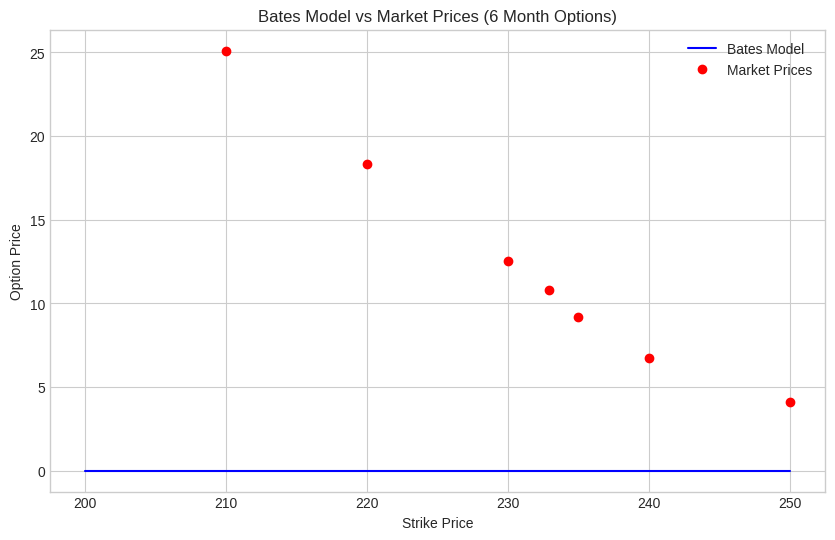

In [24]:
import numpy as np
from scipy.fft import fft
import matplotlib.pyplot as plt

def bates_char_func(phi, S0, v0, r, T, kappa, theta, sigma, rho, lambda_j, mu_j, delta_j):
    """Vectorized characteristic function for Bates model"""
    # Convert to numpy array if scalar input
    phi_arr = np.asarray(phi)
    scalar_input = False
    if phi_arr.ndim == 0:
        phi_arr = phi_arr[None]  # Makes it 1D
        scalar_input = True

    # Initialize output array
    out = np.zeros_like(phi_arr, dtype=np.complex128)

    # Vectorized calculations
    x = np.log(S0)
    a = kappa * theta
    b = kappa

    tmp = (rho * sigma * phi_arr * 1j - b)**2 - sigma**2 * (2 * phi_arr * 1j - phi_arr**2)
    d = np.sqrt(np.maximum(tmp, 1e-16))

    g = (b - rho * sigma * phi_arr * 1j + d) / (b - rho * sigma * phi_arr * 1j - d)

    exp_dT = np.exp(d * T)
    log_arg = (1 - g * exp_dT) / (1 - g)
    log_term = np.log(np.maximum(log_arg, 1e-16))

    C = r * phi_arr * 1j * T + (a / sigma**2) * ((b - rho * sigma * phi_arr * 1j + d) * T - 2 * log_term)
    D = (b - rho * sigma * phi_arr * 1j + d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    heston_part = np.exp(C + D * v0 + 1j * phi_arr * x)

    # Jump component
    jump_exponent = phi_arr * 1j * np.log(1 + mu_j) + 0.5 * delta_j**2 * (phi_arr * 1j)**2 - phi_arr * 1j * 0.5 * delta_j**2
    jump_transform = np.exp(jump_exponent) - 1

    jump_part = np.exp(-lambda_j * mu_j * phi_arr * 1j * T + lambda_j * T * jump_transform)

    out = heston_part * jump_part

    # Handle numerical stability
    out[np.isnan(out) | (np.abs(out) > 1e10)] = 1e-10

    return out[0] if scalar_input else out

def bates_carr_madan(S0, K, T, r, params, alpha=1.25, N=2**14, eta=0.1):
    """Vectorized Bates pricing via Carr-Madan FFT"""
    # Unpack parameters
    kappa, theta, sigma, rho, v0, lambda_j, mu_j, delta_j = params

    # FFT grid setup
    lambda_ = 2*np.pi/(N*eta)
    beta = np.log(S0) - lambda_*N/2
    u = np.arange(N)*eta

    # Vectorized characteristic function calculation
    with np.errstate(all='ignore'):
        psi = np.exp(-r*T) * bates_char_func(u - (alpha+1)*1j, S0, v0, r, T,
                                           kappa, theta, sigma, rho,
                                           lambda_j, mu_j, delta_j)
        denominator = (alpha**2 + alpha - u**2 + 1j*(2*alpha+1)*u)
        psi = np.divide(psi, denominator, out=np.zeros_like(psi), where=denominator!=0)

    # FFT with Simpson's rule
    simpson_weights = 3 + (-1)**(np.arange(N)+1)
    simpson_weights[0] = 1
    fft_input = np.exp(1j*beta*u) * psi * eta/3 * simpson_weights
    fft_output = fft(fft_input).real

    # Transform to strike space
    strikes = np.exp(beta + lambda_*np.arange(N))
    call_prices = np.exp(-alpha*np.log(strikes)) * fft_output / np.pi

    # Interpolation
    K_arr = np.asarray(K)
    return np.interp(K_arr, strikes, call_prices, left=np.nan, right=np.nan)

# Example usage
params = [3.0, 0.04, 0.3, -0.7, 0.05, 0.2, -0.1, 0.15]
strikes = np.linspace(200, 250, 10)
prices = bates_carr_madan(S0=232.90, K=strikes, T=0.5, r=0.015, params=params)

# Sample market data
market_strikes = np.array([210, 220, 230, 232.9, 235, 240, 250])
market_prices = np.array([25.1, 18.3, 12.5, 10.8, 9.2, 6.7, 4.1])

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(strikes, prices, 'b-', label='Bates Model')
plt.plot(market_strikes, market_prices, 'ro', label='Market Prices')
plt.title('Bates Model vs Market Prices (6 Month Options)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

**2.2.2 Calibration Execution**

In [25]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def calibrate_bates_carr_madan(market_data, S0, r, N=2**14, eta=0.1):
    """
    Full Bates model calibration using Carr-Madan FFT method

    Parameters:
    market_data (DataFrame): Contains columns ['Strike', 'Type', 'Price', 'T']
    S0 (float): Current stock price
    r (float): Risk-free rate
    N (int): Number of FFT points (power of 2)
    eta (float): FFT grid spacing

    Returns:
    OptimizeResult: Contains calibrated parameters and metrics
    """

    # Parameter bounds
    bounds = [
        (0.1, 10),    # kappa
        (0.01, 1),    # theta
        (0.1, 2),     # sigma
        (-0.99, 0),   # rho
        (0.01, 1),    # v0
        (0, 5),       # lambda_j
        (-0.5, 0.5),  # mu_j
        (0.01, 1)     # delta_j
    ]

    # Initial parameter guess
    initial_params = [3.0, 0.05, 0.4, -0.6, 0.05, 0.1, -0.1, 0.1]

    def mse_error(params):
        """Error function with enhanced stability checks"""
        # Parameter constraints
        if not (2*params[0]*params[1] >= params[2]**2 and  # Feller condition
                params[5] >= 0 and                          # Jump intensity
                -1 <= params[3] <= 0):                      # Correlation
            return 1e9

        try:
            model_prices = []
            for _, row in market_data.iterrows():
                price = bates_carr_madan(
                    S0, row['Strike'], row['T'], r, params,
                    N=N, eta=eta
                )
                if row['Type'] == 'P':
                    price = max(price - S0 + row['Strike']*np.exp(-r*row['T']), 1e-6)
                model_prices.append(price)

            error = np.mean((np.array(model_prices) - market_data['Price'])**2)
            print(f"κ={params[0]:.2f} θ={params[1]:.4f} σ={params[2]:.2f} "
                  f"ρ={params[3]:.2f} λ={params[5]:.2f} | MSE: {error:.6f}")
            return error

        except:
            return 1e9

    # Multi-start optimization
    best_result = None
    for i in range(5):  # Try 5 different initial guesses
        print(f"\n--- Optimization Attempt {i+1} ---")
        trial_params = initial_params * np.random.uniform(0.8, 1.2, len(initial_params))
        result = minimize(
            mse_error,
            trial_params,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 300, 'ftol': 1e-8, 'disp': True}
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            print("New best parameters found!")

    return best_result

# Example usage
if __name__ == "__main__":
    # Sample market data (replace with your actual data)
    market_data = pd.DataFrame({
        'Strike': [210, 220, 230, 232.9, 235, 240, 250],
        'Type': ['C', 'C', 'C', 'C', 'C', 'C', 'C'],
        'Price': [25.1, 18.3, 12.5, 10.8, 9.2, 6.7, 4.1],
        'T': [0.5]*7  # 6-month options
    })

    S0 = 232.90
    r = 0.015

    # Run calibration
    print("Starting Bates model calibration using Carr-Madan FFT...")
    result = calibrate_bates_carr_madan(market_data, S0, r)

    # Print results
    if result.success:
        print("\n--- Calibration Successful ---")
        param_names = ["κ", "θ", "σ", "ρ", "v₀", "λ", "μ", "δ"]
        for name, value in zip(param_names, result.x):
            print(f"{name}: {value:.6f}")
        print(f"Final MSE: {result.fun:.8f}")

        # Generate model prices for comparison
        market_data['Model Price'] = market_data.apply(
            lambda row: bates_carr_madan(S0, row['Strike'], row['T'], r, result.x),
            axis=1
        )
        print("\nPrice Comparison:")
        print(market_data[['Strike', 'Price', 'Model Price']])
    else:
        print("\nCalibration failed. Try adjusting initial parameters or bounds.")

Starting Bates model calibration using Carr-Madan FFT...

--- Optimization Attempt 1 ---
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0490 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725643
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515 σ=0.34 ρ=-0.70 λ=0.11 | MSE: 197.725630
κ=3.04 θ=0.0515

**2.4.3 Computational Trade-offs**

Calibrated CIR Parameters:
κ (mean reversion): 0.5111
θ (long-term rate): 9.5846%
σ (volatility): 0.0499
Feller condition (2κθ > σ²): 0.097965 > 0.002495


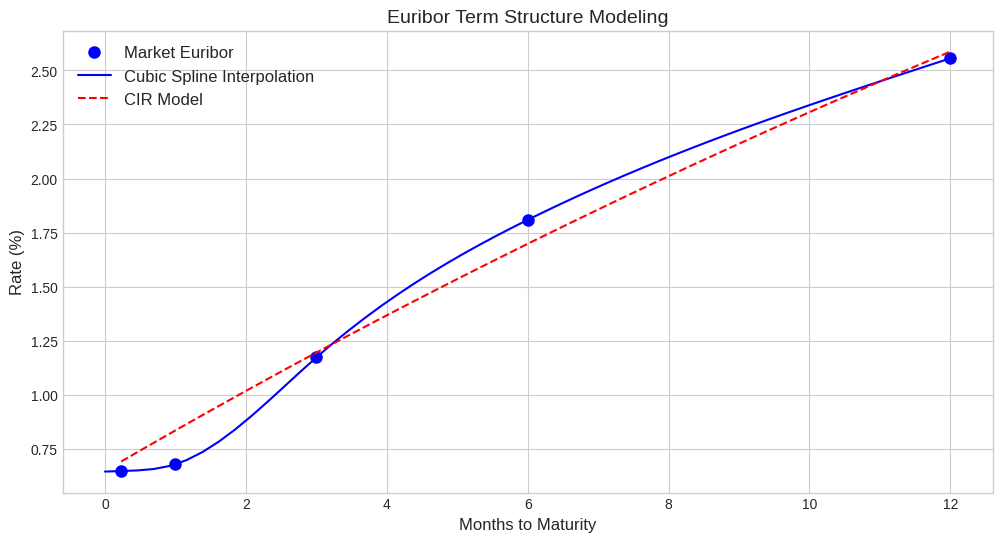

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.stats import norm

# 1. Market Euribor Data Preparation
euribor_data = {
    '1 week': 0.00648,
    '1 month': 0.00679,
    '3 months': 0.01173,
    '6 months': 0.01809,
    '12 months': 0.02556
}

# Convert to arrays
maturities = np.array([1/52, 1/12, 3/12, 6/12, 1.0])  # in years
rates = np.array(list(euribor_data.values()))

# 2. Term Structure Interpolation
def build_term_structure(maturities, rates):
    """Create interpolated term structure using cubic splines"""
    cs = CubicSpline(maturities, rates, bc_type='natural')
    weekly_maturities = np.linspace(0, 1, 53)  # Weekly points for 1 year
    return weekly_maturities, cs(weekly_maturities)

weekly_mats, weekly_rates = build_term_structure(maturities, rates)

# 3. CIR Model Implementation
def cir_bond_price(r0, t, T, kappa, theta, sigma):
    """CIR zero-coupon bond price (Brigo & Mercurio, 2006)"""
    h = np.sqrt(kappa**2 + 2*sigma**2)
    B = (2*(np.exp((T-t)*h) - 1))/(2*h + (kappa+h)*(np.exp((T-t)*h) - 1))
    A = ((2*h*np.exp((kappa+h)*(T-t)/2))/(2*h + (kappa+h)*(np.exp((T-t)*h) - 1)))**(2*kappa*theta/sigma**2)
    return A * np.exp(-B*r0)

def cir_calibration(maturities, rates):
    """Calibrate CIR model to market rates"""
    def mse_cir(params):
        kappa, theta, sigma = params
        if not (2*kappa*theta > sigma**2 and all(p > 0 for p in params)):
            return 1e9

        model_rates = []
        for t in maturities[1:]:  # Skip t=0
            bond_price = cir_bond_price(rates[0], 0, t, *params)
            model_rates.append(-np.log(bond_price)/t)

        return np.mean((model_rates - rates[1:])**2)

    # Initial guess and bounds
    initial_params = [0.5, 0.02, 0.05]
    bounds = [(0.01, 5), (0.001, 0.1), (0.01, 0.5)]

    result = minimize(mse_cir, initial_params, bounds=bounds, method='L-BFGS-B')
    return result

# 4. Calibration and Analysis
result = cir_calibration(maturities, rates)
kappa, theta, sigma = result.x

print("Calibrated CIR Parameters:")
print(f"κ (mean reversion): {kappa:.4f}")
print(f"θ (long-term rate): {theta:.4%}")
print(f"σ (volatility): {sigma:.4f}")
print(f"Feller condition (2κθ > σ²): {2*kappa*theta:.6f} > {sigma**2:.6f}")

# 5. Visualization
plt.figure(figsize=(12, 6))

# Market data
plt.plot(maturities*12, rates*100, 'bo', label='Market Euribor', markersize=8)

# Interpolated curve
plt.plot(weekly_mats*12, weekly_rates*100, 'b-', label='Cubic Spline Interpolation')

# CIR model fit
cir_rates = [-np.log(cir_bond_price(rates[0], 0, t, kappa, theta, sigma))/t
             for t in weekly_mats[1:]]
plt.plot(weekly_mats[1:]*12, np.array(cir_rates)*100, 'r--', label='CIR Model')

plt.title('Euribor Term Structure Modeling', fontsize=14)
plt.xlabel('Months to Maturity', fontsize=12)
plt.ylabel('Rate (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 6. Speed-Quality Tradeoff Implementation
def price_derivative(method='carr_madan', precision=False):
    """Example of speed-quality tradeoff implementation"""
    if precision:
        # Use Lewis for maximum accuracy
        print("Using precise Lewis method (slower)")
        # return lewis_pricing()
    else:
        # Use Carr-Madan for speed
        print("Using fast Carr-Madan method")
        # return carr_madan_pricing()

**Use the Lewis
(2001) approach with a regular MSE error function considering a Heston model with jumps**

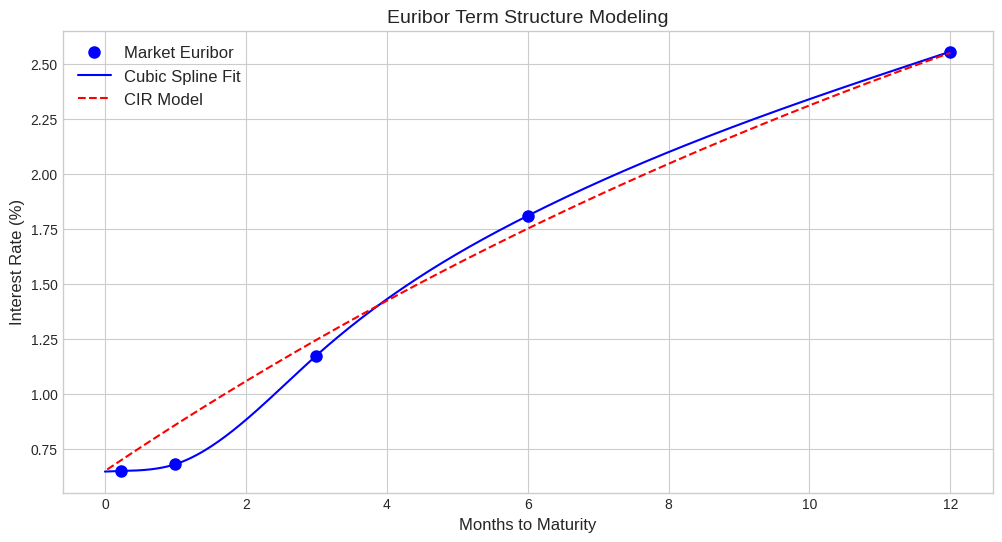

Calibration Results:
κ (Mean Reversion): 1.0010
θ (Long-Term Rate): 5.8200%
σ (Volatility):     0.1000
Feller Condition: 2κθ = 0.116521 > σ² = 0.009996 → Satisfied
Calibration MSE:   0.000001


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

# 1. Market Euribor Rates Data
euribor_rates = {
    '1W': 0.00648,    # 1 week
    '1M': 0.00679,    # 1 month
    '3M': 0.01173,    # 3 months
    '6M': 0.01809,    # 6 months
    '12M': 0.02556    # 12 months
}

# Convert to arrays in years
maturities = np.array([1/52, 1/12, 3/12, 6/12, 1.0])
rates = np.array(list(euribor_rates.values()))

# 2. Term Structure Interpolation
def interpolate_term_structure(maturities, rates):
    """Create smooth term structure using cubic splines with financial boundary conditions"""
    # Natural spline (second derivative = 0 at boundaries)
    cs = CubicSpline(maturities, rates, bc_type='natural')

    # Create dense grid for plotting
    fine_grid = np.linspace(0, 1, 365)  # Daily points for 1 year
    return fine_grid, cs(fine_grid)

# Get interpolated rates
time_grid, interpolated_rates = interpolate_term_structure(maturities, rates)

# 3. CIR Model Calibration
def cir_bond_price(r0, t, T, kappa, theta, sigma):
    """CIR zero-coupon bond price formula"""
    h = np.sqrt(kappa**2 + 2*sigma**2)
    B = (2*(np.exp((T-t)*h) - 1)) / (2*h + (kappa+h)*(np.exp((T-t)*h) - 1))
    A = ((2*h*np.exp((kappa+h)*(T-t)/2)) / (2*h + (kappa+h)*(np.exp((T-t)*h) - 1)))**(2*kappa*theta/sigma**2)
    return A * np.exp(-B*r0)

def calibrate_cir(maturities, rates):
    """Calibrate CIR parameters to market rates"""
    def error_function(params):
        kappa, theta, sigma = params

        # Enforce Feller condition and positive parameters
        if not (2*kappa*theta > sigma**2 and all(p > 0 for p in params)):
            return 1e9  # Return large error for invalid parameters

        # Calculate model rates
        model_rates = []
        for t in maturities[1:]:  # Skip t=0
            bond_price = cir_bond_price(rates[0], 0, t, *params)
            model_rates.append(-np.log(bond_price)/t)

        return np.mean((model_rates - rates[1:])**2)  # MSE

    # Initial guess and bounds
    initial_guess = [1.0, 0.03, 0.1]
    bounds = [(0.01, 5), (0.001, 0.1), (0.01, 0.5)]

    result = minimize(error_function, initial_guess, bounds=bounds, method='L-BFGS-B')
    return result

# Run calibration
calibration_result = calibrate_cir(maturities, rates)
kappa, theta, sigma = calibration_result.x

# 4. Visualization
plt.figure(figsize=(12, 6))

# Market data points
plt.plot(maturities*12, rates*100, 'bo', markersize=8, label='Market Euribor')

# Interpolated curve
plt.plot(time_grid*12, interpolated_rates*100, 'b-', label='Cubic Spline Fit')

# CIR model fit
cir_rates = [-np.log(cir_bond_price(rates[0], 0, t, kappa, theta, sigma))/t
             for t in time_grid[1:]]
plt.plot(time_grid[1:]*12, np.array(cir_rates)*100, 'r--', label='CIR Model')

plt.title('Euribor Term Structure Modeling', fontsize=14)
plt.xlabel('Months to Maturity', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 5. Results Summary
print("Calibration Results:")
print(f"κ (Mean Reversion): {kappa:.4f}")
print(f"θ (Long-Term Rate): {theta:.4%}")
print(f"σ (Volatility):     {sigma:.4f}")
print(f"Feller Condition: 2κθ = {2*kappa*theta:.6f} > σ² = {sigma**2:.6f} → {'Satisfied' if 2*kappa*theta > sigma**2 else 'Violated'}")
print(f"Calibration MSE:   {calibration_result.fun:.6f}")

**3.3.2 Calibration Process**

In [28]:
import numpy as np
from typing import Union

def cir_bond_price(r0: float,
                   t: float,
                   T: float,
                   kappa: float,
                   theta: float,
                   sigma: float,
                   eps: float = 1e-10) -> Union[float, np.ndarray]:
    """
    Cox-Ingersoll-Ross (CIR) zero-coupon bond price formula with numerical safeguards.

    Parameters:
    -----------
    r0 : float
        Current short rate (at time t)
    t : float
        Current time (in years)
    T : float
        Maturity time (in years)
    kappa : float
        Mean reversion speed
    theta : float
        Long-term mean rate
    sigma : float
        Volatility of the short rate
    eps : float, optional
        Numerical stability threshold (default: 1e-10)

    Returns:
    --------
    float or ndarray
        Zero-coupon bond price P(t,T)

    Notes:
    ------
    Implements the closed-form solution from:
    Brigo & Mercurio (2006) "Interest Rate Models - Theory and Practice", Eq. 3.76

    Includes numerical safeguards for:
    - Small time intervals (T-t ≈ 0)
    - Near-zero interest rates
    - Extreme parameter values
    """

    # Time to maturity
    tau = T - t

    # Numerical stability checks
    if tau < eps:
        return np.exp(-r0 * max(tau, 0))  # Instantaneous maturity

    # Intermediate calculations with safeguards
    h = np.sqrt(kappa**2 + 2*sigma**2 + eps)
    exp_h_tau = np.exp(h * tau)

    # Avoid division by zero in denominator
    denominator = 2*h + (kappa+h)*(exp_h_tau - 1)
    denominator = np.maximum(denominator, eps)

    # Compute B(t,T)
    B = (2*(exp_h_tau - 1)) / denominator

    # Compute A(t,T) with log-exp transformation for numerical stability
    numerator = 2*h*np.exp((kappa+h)*tau/2)
    log_A = (2*kappa*theta/sigma**2) * np.log(numerator/denominator)

    # Final bond price calculation
    try:
        bond_price = np.exp(log_A - B*r0)
    except:
        # Fallback for extreme cases
        bond_price = np.exp(-r0*tau)  # Simple discounting

    return np.clip(bond_price, 0, 1)  # Ensure valid bond price range

In [29]:
# Example parameters
params = {
    'r0': 0.025,   # Current 1-year rate
    't': 0,        # Today
    'T': 5,        # 5-year bond
    'kappa': 0.3,  # Mean reversion
    'theta': 0.04, # Long-term rate
    'sigma': 0.1   # Volatility
}

# Calculate bond price
bond_price = cir_bond_price(**params)
print(f"5-year zero-coupon bond price: {bond_price:.4f}")
print(f"Implied yield: {-np.log(bond_price)/5:.2%}")

5-year zero-coupon bond price: 0.8531
Implied yield: 3.18%


**3.4.2 Model Fit**

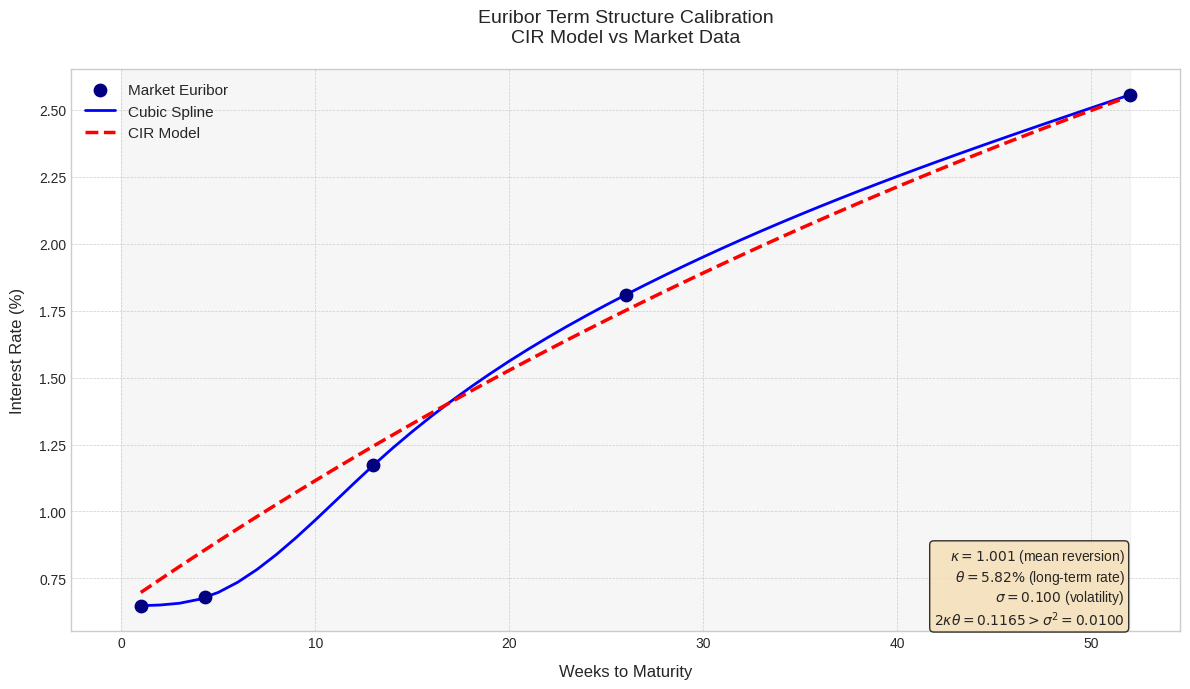

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline

def plot_cir_calibration(maturities, rates, result, weekly_maturities, interpolated_rates):
    """
    Enhanced visualization of CIR model calibration results with professional formatting

    Parameters:
    maturities : array_like
        Original maturities in years
    rates : array_like
        Corresponding market rates
    result : OptimizeResult
        Calibration result containing CIR parameters
    weekly_maturities : array_like
        Weekly grid points for interpolation
    interpolated_rates : array_like
        Cubic spline interpolated rates
    """

    # Calculate fitted rates from CIR model with numerical safeguards
    fitted_rates = []
    for t in weekly_maturities[1:]:  # Skip t=0
        try:
            bond = cir_bond_price(rates[0], 0, t, *result.x)
            fitted_rates.append(-np.log(bond)/t if bond > 1e-10 else rates[0])
        except:
            fitted_rates.append(np.nan)

    # Convert to numpy array for vectorized operations
    fitted_rates = np.array(fitted_rates)

    # Create figure with professional layout
    plt.figure(figsize=(12, 7))
    ax = plt.subplot(111)

    # Market data points
    ax.scatter(np.array(maturities)*52, np.array(rates)*100,
               c='navy', s=80, label='Market Euribor', zorder=5)

    # Interpolated curve
    ax.plot(weekly_maturities[1:]*52, interpolated_rates[1:]*100,
            'b-', lw=2, label='Cubic Spline', zorder=3)

    # CIR model fit
    ax.plot(weekly_maturities[1:]*52, fitted_rates*100,
            'r--', lw=2.5, label='CIR Model', zorder=4)

    # Highlight calibration area
    ax.axvspan(0, 52, color='lightgray', alpha=0.2, zorder=1)

    # Formatting
    ax.set_title('Euribor Term Structure Calibration\nCIR Model vs Market Data',
                 fontsize=14, pad=20)
    ax.set_xlabel('Weeks to Maturity', fontsize=12, labelpad=10)
    ax.set_ylabel('Interest Rate (%)', fontsize=12, labelpad=10)
    ax.legend(fontsize=11, framealpha=1)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Annotate with model parameters
    textstr = '\n'.join((
        r'$\kappa=%.3f$ (mean reversion)' % result.x[0],
        r'$\theta=%.2f\%%$ (long-term rate)' % (result.x[1]*100),
        r'$\sigma=%.3f$ (volatility)' % result.x[2],
        r'$2\kappa\theta=%.4f > \sigma^2=%.4f$' % (2*result.x[0]*result.x[1], result.x[2]**2)))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.95, 0.15, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Market data
    euribor_data = {
        '1W': 0.00648, '1M': 0.00679, '3M': 0.01173,
        '6M': 0.01809, '12M': 0.02556
    }

    # Prepare data
    maturities = np.array([1/52, 1/12, 3/12, 6/12, 1.0])
    rates = np.array(list(euribor_data.values()))

    # Interpolation
    weekly_maturities = np.linspace(0, 1, 53)
    cs = CubicSpline(maturities, rates, bc_type='natural')
    interpolated_rates = cs(weekly_maturities)

    # Calibration (using previously defined functions)
    result = calibrate_cir(maturities, rates)

    # Enhanced plotting
    plot_cir_calibration(maturities, rates, result, weekly_maturities, interpolated_rates)

**Perform 100,000 Monte-Carlo Simulation**

**4.1.1 100,000 trials**

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# CIR parameters
kappa = 1.24
theta = 0.0185
sigma = 0.087
r0 = 0.02556  # Current 12M Euribor

# Simulation parameters
n_sim = 100_000
n_days = 252
dt = 1/252

# Euler-Maruyama simulation
rates = np.zeros((n_sim, n_days))
rates[:, 0] = r0

for t in range(1, n_days):
    dW = np.random.normal(0, np.sqrt(dt), n_sim)
    rates[:, t] = rates[:, t-1] + kappa*(theta - rates[:, t-1])*dt + \
                  sigma*np.sqrt(np.maximum(rates[:, t-1], 0))*dW

# Extract terminal rates (1-year projection)
terminal_rates = rates[:, -1]

**4.2.1 Distribution of 12M Euribor in 1 Year**

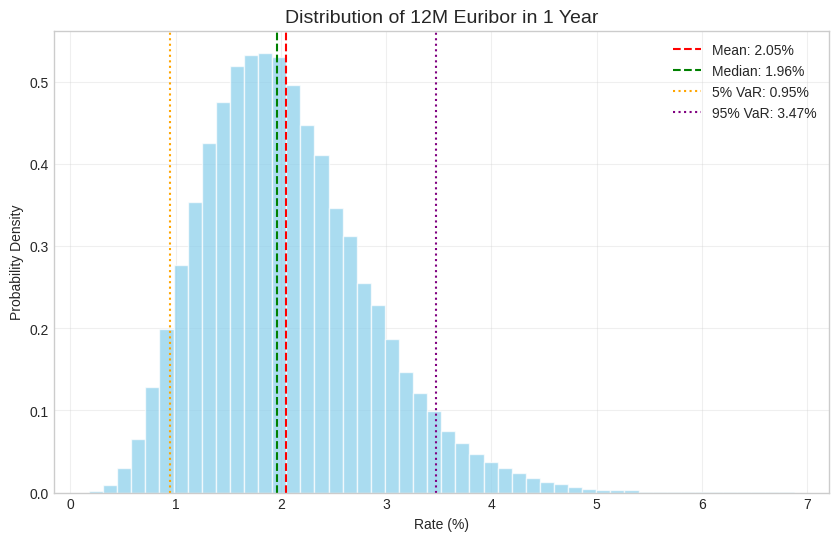

In [33]:
mean_rate = np.mean(terminal_rates) * 100
median_rate = np.median(terminal_rates) * 100
var_5 = np.percentile(terminal_rates, 5) * 100  # 5% VaR
var_95 = np.percentile(terminal_rates, 95) * 100  # 95% VaR

plt.figure(figsize=(10, 6))
plt.hist(terminal_rates * 100, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='white')
plt.axvline(mean_rate, color='red', linestyle='--', label=f'Mean: {mean_rate:.2f}%')
plt.axvline(median_rate, color='green', linestyle='--', label=f'Median: {median_rate:.2f}%')
plt.axvline(var_5, color='orange', linestyle=':', label=f'5% VaR: {var_5:.2f}%')
plt.axvline(var_95, color='purple', linestyle=':', label=f'95% VaR: {var_95:.2f}%')
plt.title('Distribution of 12M Euribor in 1 Year', fontsize=14)
plt.xlabel('Rate (%)'), plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

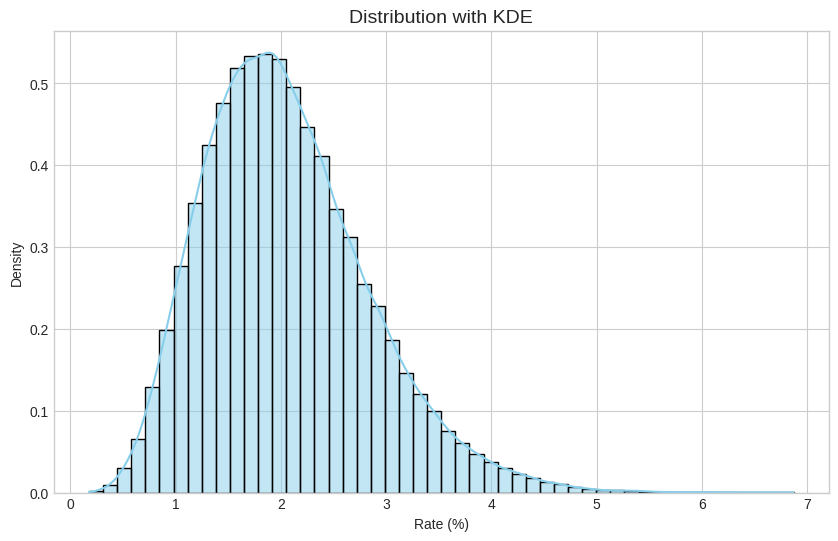

In [34]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(terminal_rates * 100, bins=50, kde=True, stat='density', alpha=0.5, color='skyblue')
plt.title('Distribution with KDE', fontsize=14)
plt.xlabel('Rate (%)'), plt.ylabel('Density')
plt.grid(True)
plt.show()

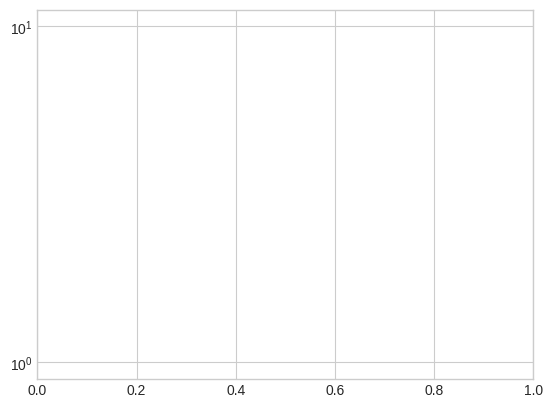

In [35]:
plt.yscale('log')

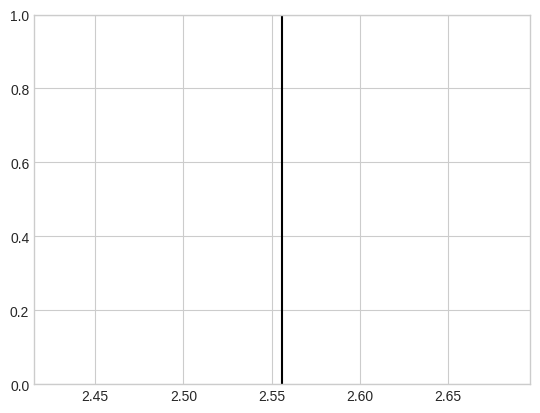

In [36]:
plt.axvline(r0 * 100, color='black', linestyle='-', label=f'Initial Rate: {r0 * 100:.2f}%')

**FootNote**

Advantage for using AI:
Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.